# Exploratory Data Analysis — X-Health Default Prediction

**Goal:** Understand the dataset structure, distributions, missing values, and target imbalance before building the ML pipeline.

**Business context:** X-Health sells B2B health devices on credit. The `default` column indicates whether a client failed to pay (1 = default, 0 = paid on time). Understanding the data deeply is the foundation for every modeling decision that follows.

## 1. Setup & Data Loading

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

SEED = 42
DATA_PATH = '../data/dataset_2021-5-26-10-14.csv'
TARGET = 'default'

In [3]:
df_raw = pd.read_csv(DATA_PATH, sep='\t', encoding='utf-8')
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (117273, 22)


,default_3months,ioi_36months,ioi_3months,valor_por_vencer,valor_vencido,valor_quitado,quant_protestos,valor_protestos,quant_acao_judicial,acao_judicial_valor,...,dividas_vencidas_qtd,falencia_concordata_qtd,tipo_sociedade,opcao_tributaria,atividade_principal,forma_pagamento,valor_total_pedido,month,year,default
0,0,58.000000,18.236092,0.00,0.0,242100.70,0,0.0,0,0.0,...,0,0,empresario (individual),simples nacional,papelaria,30/60/90,34665.674938,6,2019,0
1,1,16.052632,7.500000,224132.85,0.0,4960846.21,0,0.0,0,0.0,...,0,0,sociedade empresaria limitada,missing,com de equipamentos de informatica,30/60/90,7134.489373,10,2018,0
2,0,13.250000,3.904762,513043.83,0.0,158631.93,1,1800.0,0,0.0,...,0,0,sociedade empresaria limitada,simples nacional,servicos de vigilancia e guarda,missing,72653.621143,4,2018,0


## 2. Basic Overview

In [4]:
df_raw.dtypes

default_3months                  int64
ioi_36months                   float64
ioi_3months                    float64
valor_por_vencer               float64
valor_vencido                  float64
valor_quitado                  float64
quant_protestos                  int64
valor_protestos                float64
quant_acao_judicial              int64
acao_judicial_valor            float64
participacao_falencia_valor    float64
dividas_vencidas_valor         float64
dividas_vencidas_qtd             int64
falencia_concordata_qtd          int64
tipo_sociedade                     str
opcao_tributaria                   str
atividade_principal                str
forma_pagamento                    str
valor_total_pedido             float64
month                            int64
year                             int64
default                          int64
dtype: object

In [7]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
default_3months,117273.0,NaN,NaN,NaN,0.148721,0.853794,0.0,0.0,0.0,0.0,26.0
ioi_36months,117273.0,NaN,NaN,NaN,55.582906,60.98924,1.0,20.166667,38.0,69.75,951.0
ioi_3months,117273.0,NaN,NaN,NaN,17.106291,10.993605,1.0,11.121543,16.0,18.24885,90.0
valor_por_vencer,117273.0,NaN,NaN,NaN,64213.837696,525254.625651,0.0,565.74,4451.74,20062.96,72197586.36
valor_vencido,117273.0,NaN,NaN,NaN,2454.042564,80933.125138,0.0,0.0,0.0,0.0,13150500.0
valor_quitado,117273.0,NaN,NaN,NaN,1085557.336176,7444825.413865,0.0,19442.5,81348.78,332264.3,460320322.8
quant_protestos,117273.0,NaN,NaN,NaN,0.240456,10.707825,0.0,0.0,0.0,0.0,2324.0
valor_protestos,117273.0,NaN,NaN,NaN,2051.017146,88317.579444,0.0,0.0,0.0,0.0,16305457.0
quant_acao_judicial,117273.0,NaN,NaN,NaN,0.018922,0.534034,0.0,0.0,0.0,0.0,80.0
acao_judicial_valor,117273.0,NaN,NaN,NaN,921.851051,48610.251973,0.0,0.0,0.0,0.0,8390986.0


## 3. Replacing "missing" Strings with NaN

In [10]:
df = df_raw.replace('missing', np.nan).copy()

NUMERICAL_FEATURES = [
    'default_3months', 'ioi_36months', 'ioi_3months',
    'valor_por_vencer', 'valor_vencido', 'valor_quitado',
    'quant_protestos', 'valor_protestos', 'quant_acao_judicial',
    'acao_judicial_valor', 'participacao_falencia_valor',
    'dividas_vencidas_valor', 'dividas_vencidas_qtd',
    'falencia_concordata_qtd', 'valor_total_pedido', 'month', 'year'
]

CATEGORICAL_FEATURES = [
    'tipo_sociedade', 'opcao_tributaria', 'atividade_principal', 'forma_pagamento'
]

for col in NUMERICAL_FEATURES:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Shape after cleaning: {df.shape}')
df.dtypes

Shape after cleaning: (117273, 22)


default_3months                  int64
ioi_36months                   float64
ioi_3months                    float64
valor_por_vencer               float64
valor_vencido                  float64
valor_quitado                  float64
quant_protestos                  int64
valor_protestos                float64
quant_acao_judicial              int64
acao_judicial_valor            float64
participacao_falencia_valor    float64
dividas_vencidas_valor         float64
dividas_vencidas_qtd             int64
falencia_concordata_qtd          int64
tipo_sociedade                     str
opcao_tributaria                   str
atividade_principal                str
forma_pagamento                    str
valor_total_pedido             float64
month                            int64
year                             int64
default                          int64
dtype: object

## 4. Missing Values Analysis

float64
                     missing_count  missing_pct
forma_pagamento              32477        27.69
opcao_tributaria             18325        15.63
tipo_sociedade                 608         0.52
atividade_principal            592         0.50


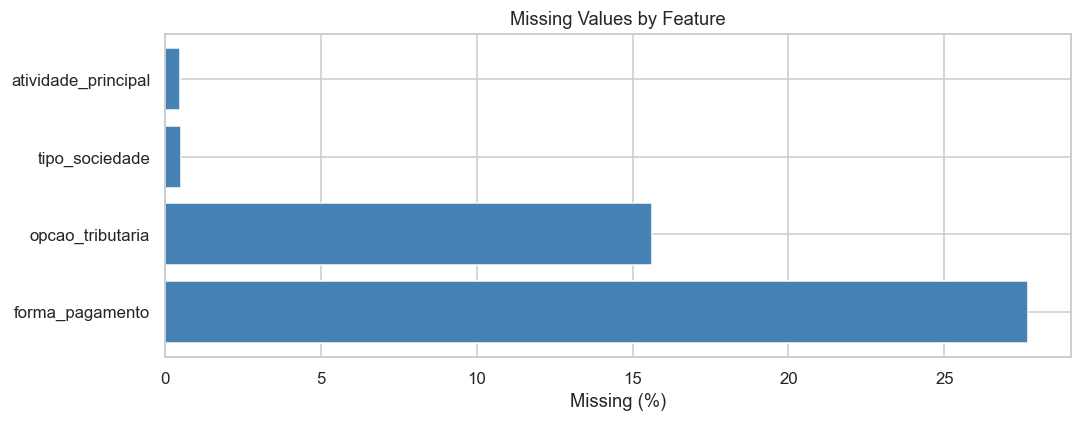

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df.missing_count > 0].sort_values('missing_pct', ascending=False)
print(missing_df)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(missing_df.index, missing_df['missing_pct'], color='steelblue')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Feature')
plt.tight_layout()
plt.show()

**Insight:** Columns with high missingness may need imputation or removal. Categorical columns with many NaNs could represent clients without Serasa records — this absence itself is informative (lower risk profile).

## 5. Target Variable — Class Imbalance

Default distribution:
         count    pct
default              
0        97728  83.33
1        19545  16.67


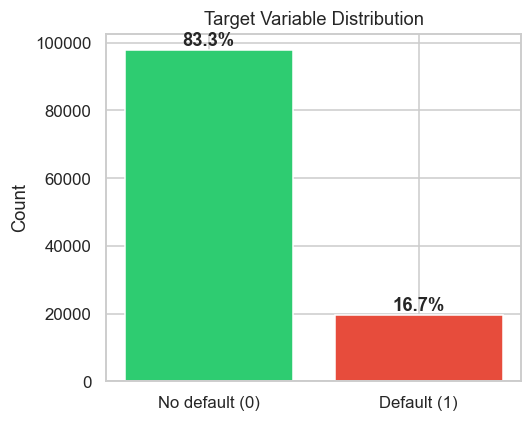

In [22]:
target_counts = df[TARGET].value_counts()
target_pct = df[TARGET].value_counts(normalize=True) * 100

print('Default distribution:')
print(pd.DataFrame({'count': target_counts, 'pct': target_pct.round(2)}))

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['No default (0)', 'Default (1)'], target_counts.values,
               color=['#2ecc71', '#e74c3c'], edgecolor='white')
for bar, pct in zip(bars, target_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 300, f'{pct:.1f}%',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Target Variable Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

**Business insight:** If the dataset is heavily imbalanced, a naive model that always predicts "no default" achieves high accuracy but provides zero value to the finance team. We must prioritize **Recall for class 1** — a missed default (False Negative) is far more costly than a false alarm (False Positive).

## 6. Numerical Features — Distributions

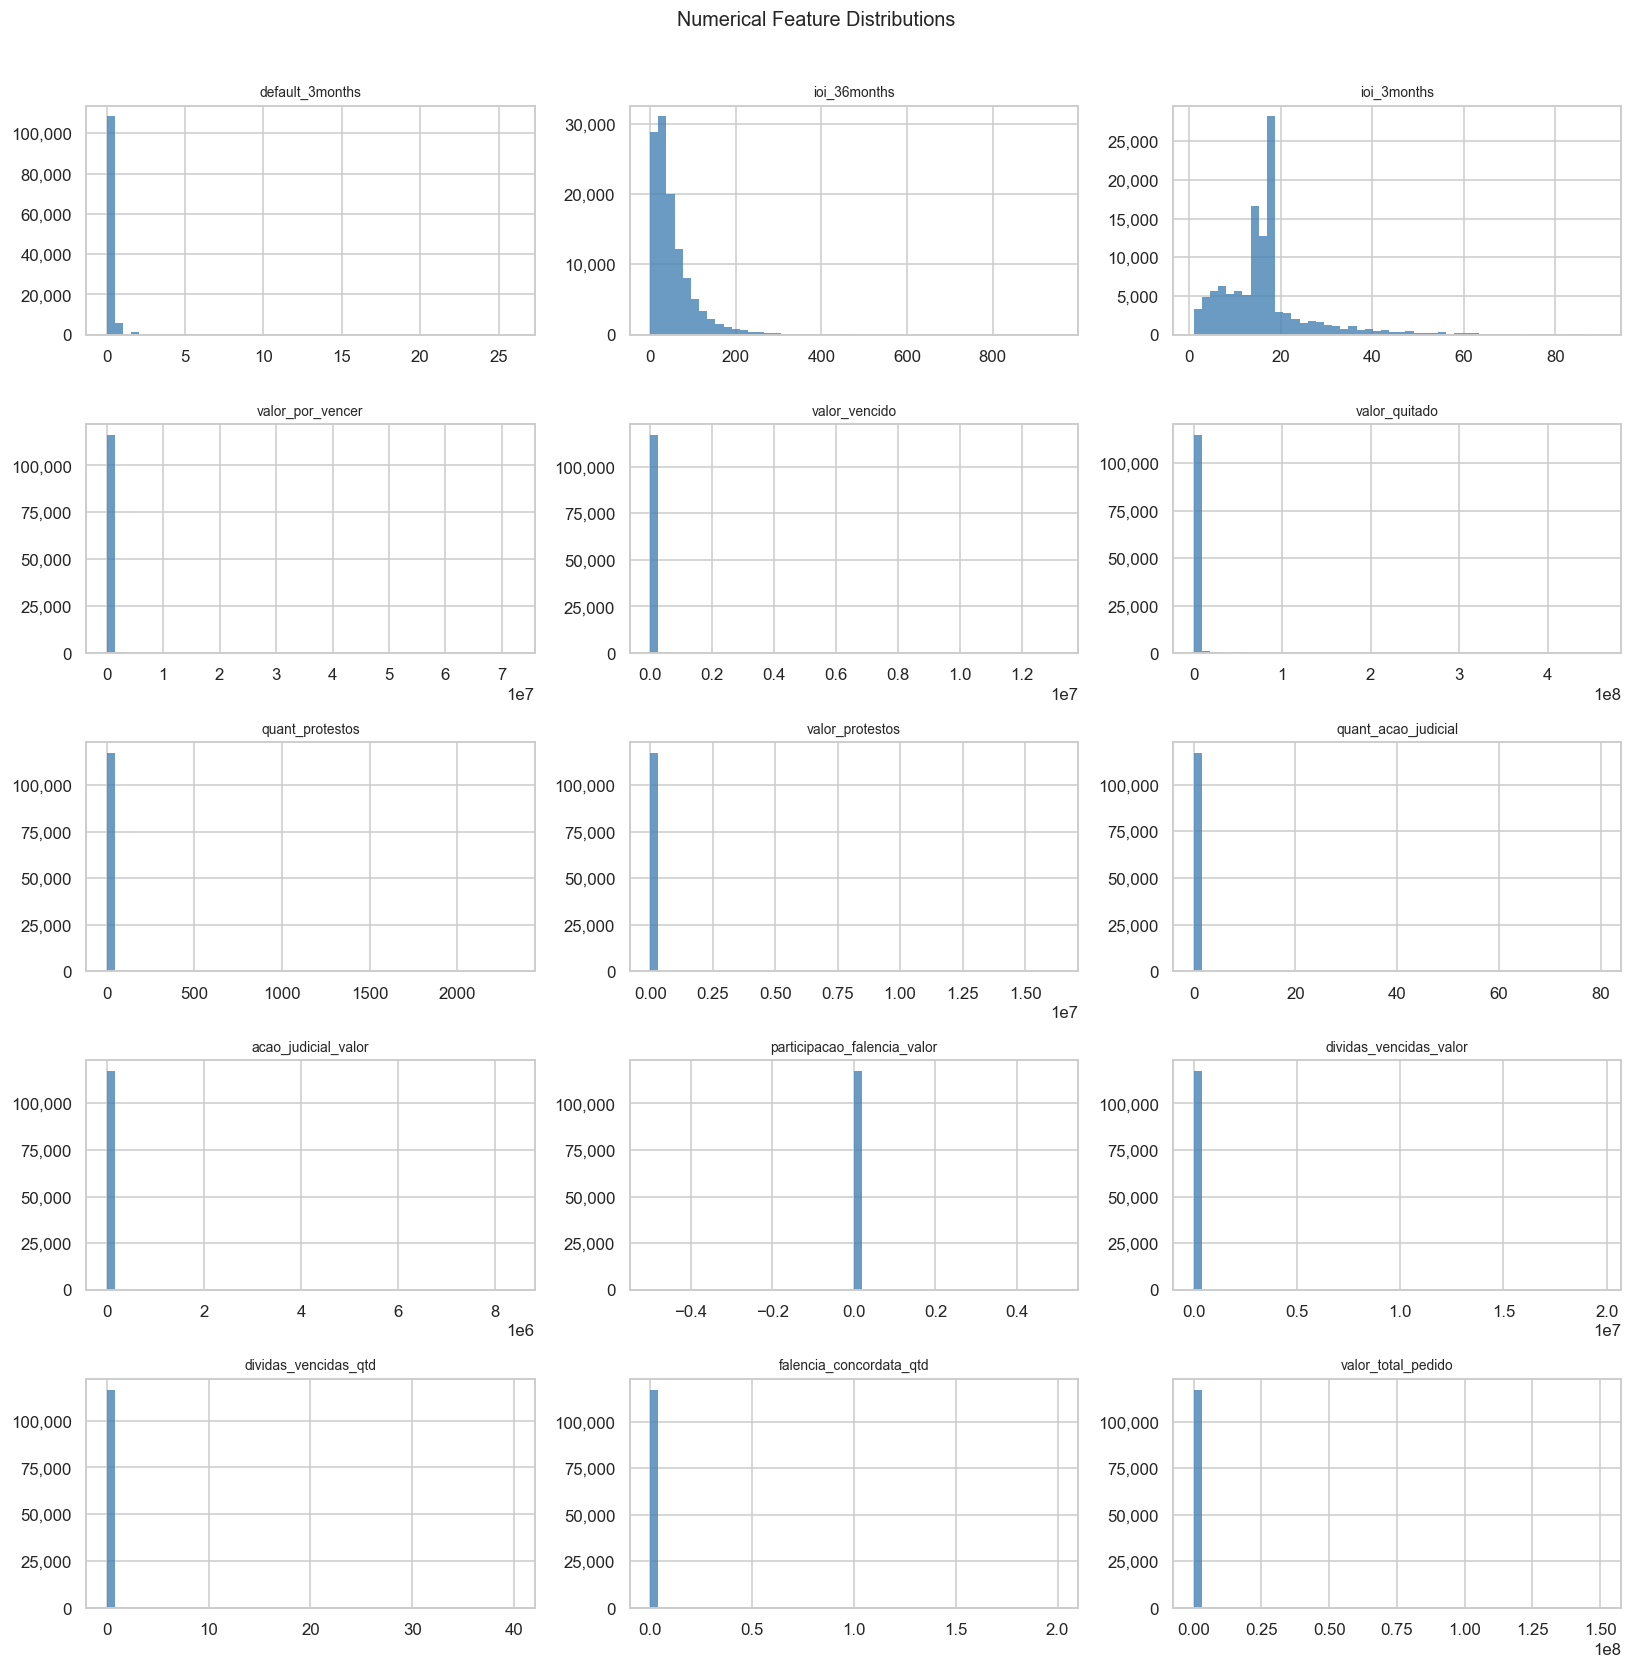

In [23]:
plot_num = [c for c in NUMERICAL_FEATURES if c not in ['month', 'year', TARGET]]

n_cols = 3
n_rows = int(np.ceil(len(plot_num) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(plot_num):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(col, fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Numerical Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Insight:** Most financial variables are heavily right-skewed — a small number of orders have very large values. This is typical in credit data and justifies using **RobustScaler** (resistant to outliers) instead of StandardScaler.

## 7. Numerical Features by Target (Default vs No Default)

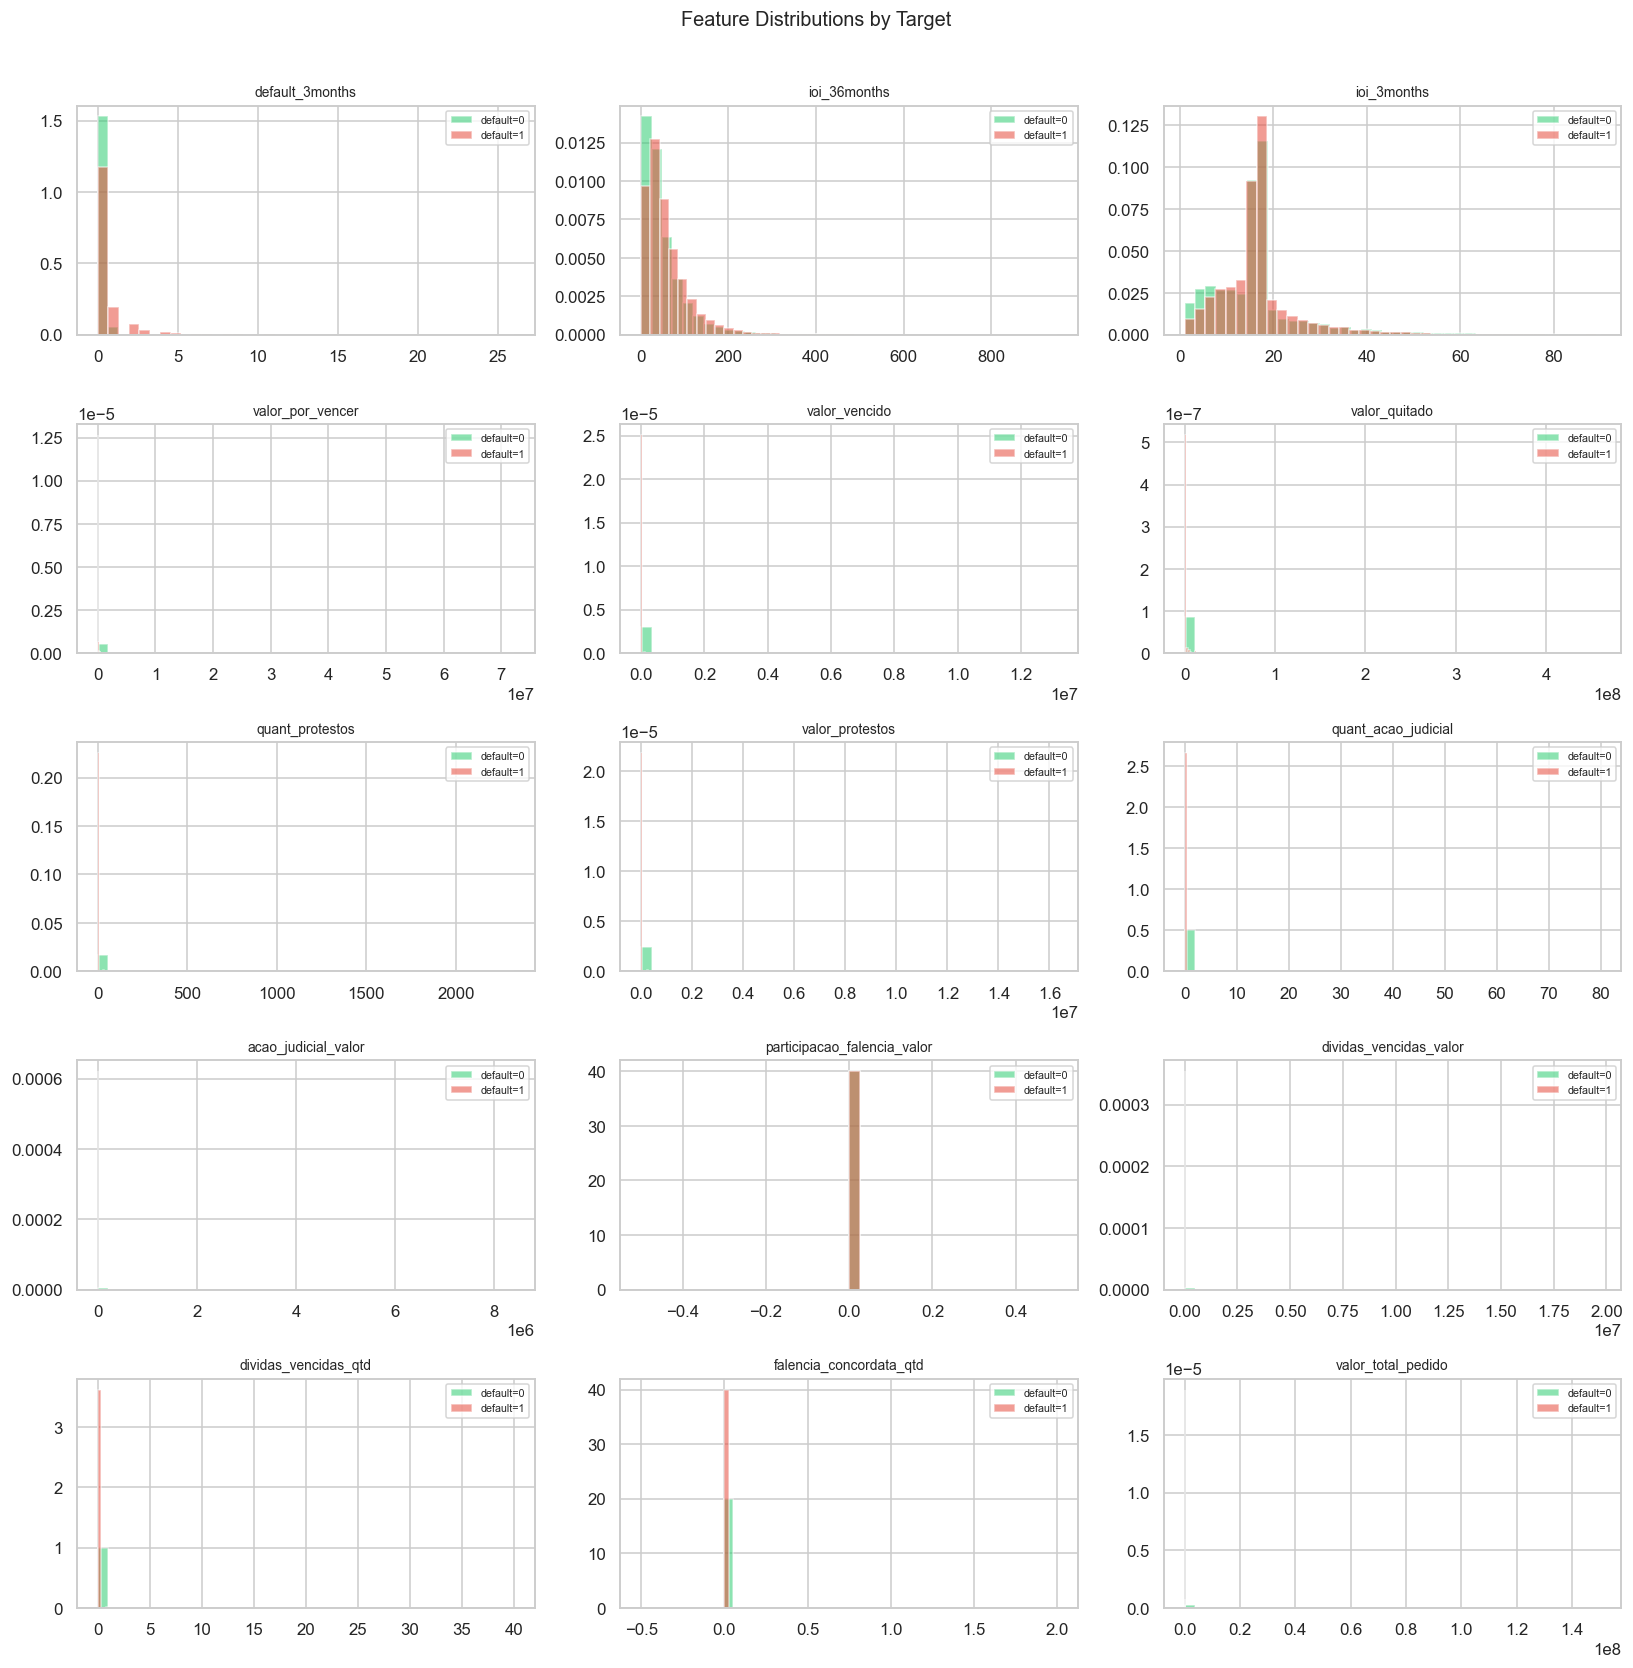

In [24]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(plot_num):
    ax = axes[i]
    for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
        data = df[df[TARGET] == label][col].dropna()
        ax.hist(data, bins=40, alpha=0.55, color=color,
                label=f'default={label}', density=True)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions by Target', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Categorical Features — Frequency & Default Rate

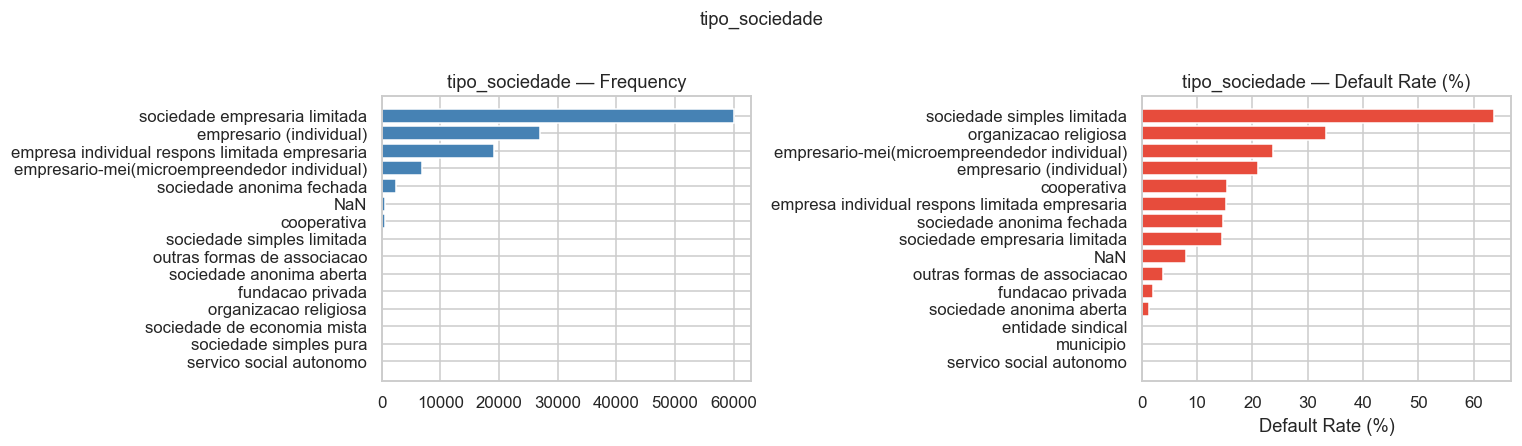

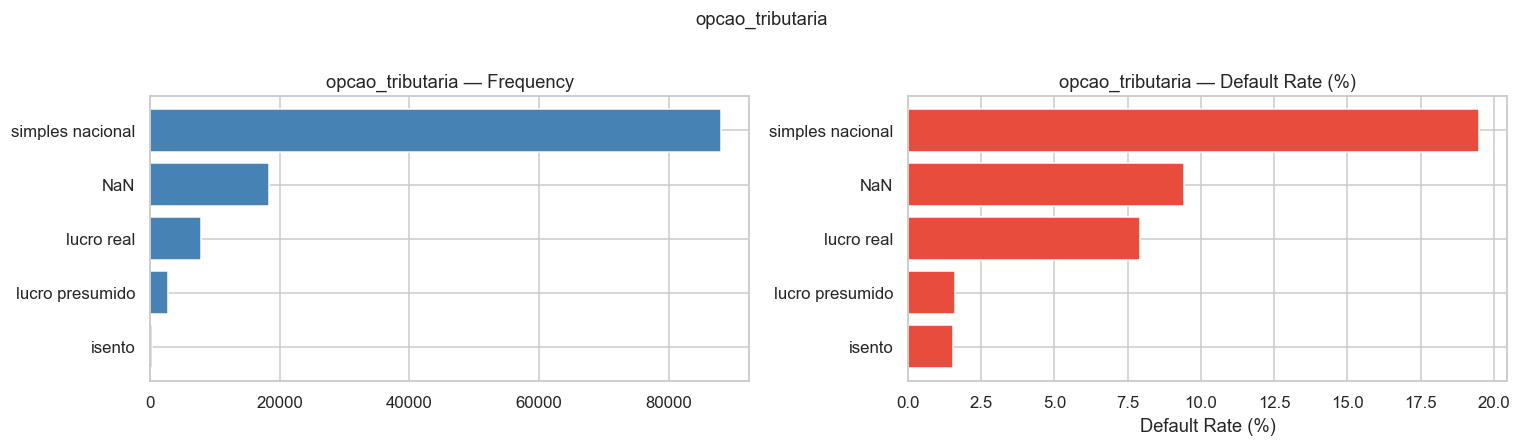

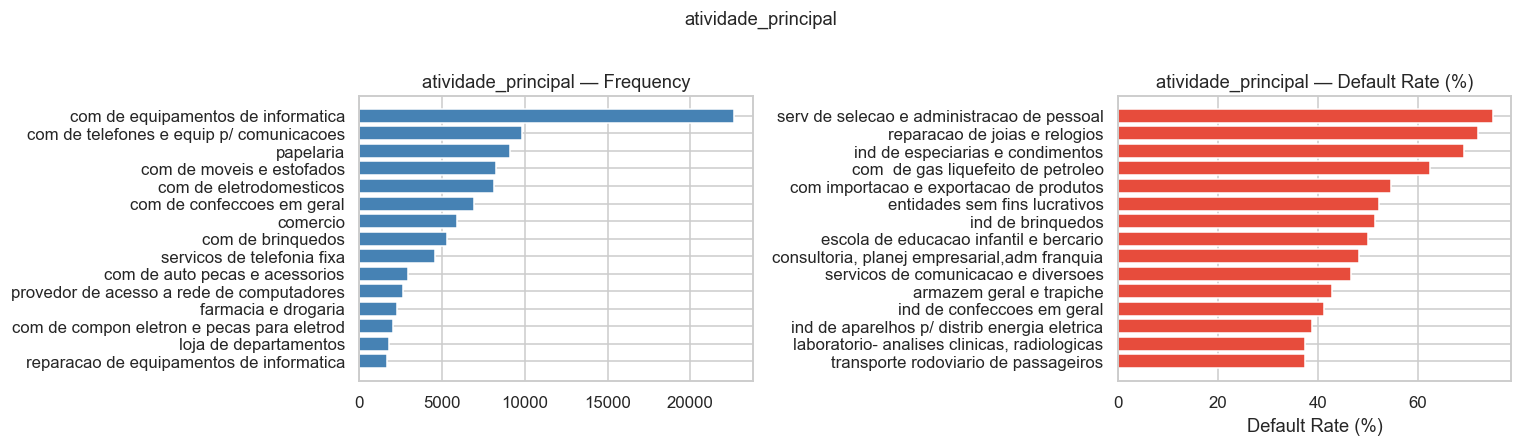

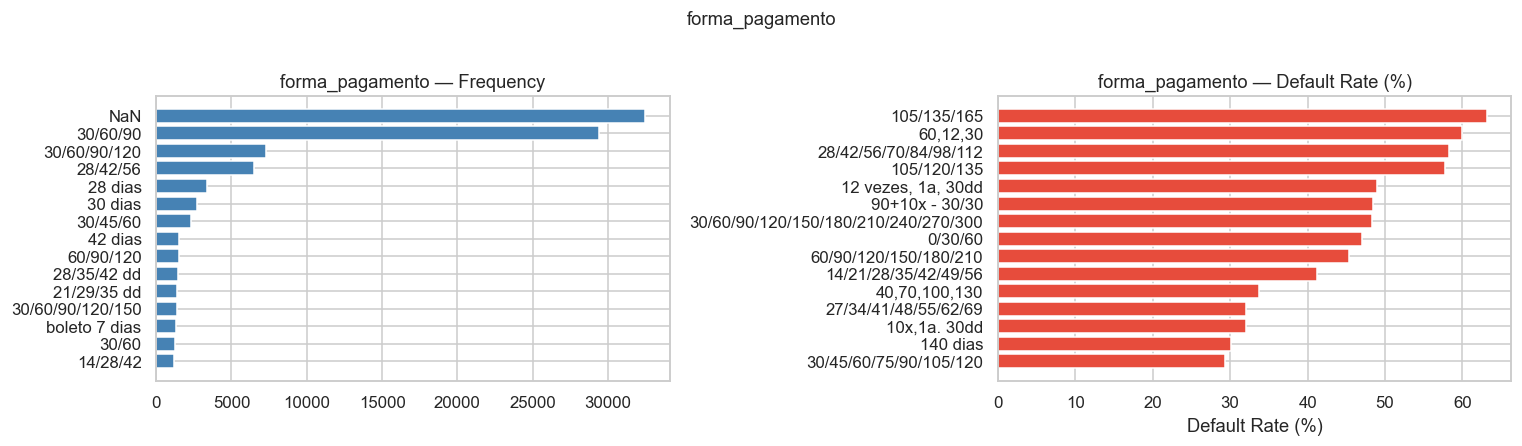

In [28]:
for col in CATEGORICAL_FEATURES:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    freq = df[col].value_counts(dropna=False).head(15)
    freq.index = freq.index.fillna('NaN').astype(str)
    axes[0].barh(freq.index, freq.values, color='steelblue')
    axes[0].set_title(f'{col} — Frequency')
    axes[0].invert_yaxis()

    rate = df.groupby(col, dropna=False)[TARGET].mean().sort_values(ascending=False).head(15)
    rate.index = rate.index.fillna('NaN').astype(str)
    axes[1].barh(rate.index, rate.values * 100, color='#e74c3c')
    axes[1].set_title(f'{col} — Default Rate (%)')
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Default Rate (%)')

    plt.suptitle(col, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

## 9. Correlation Heatmap

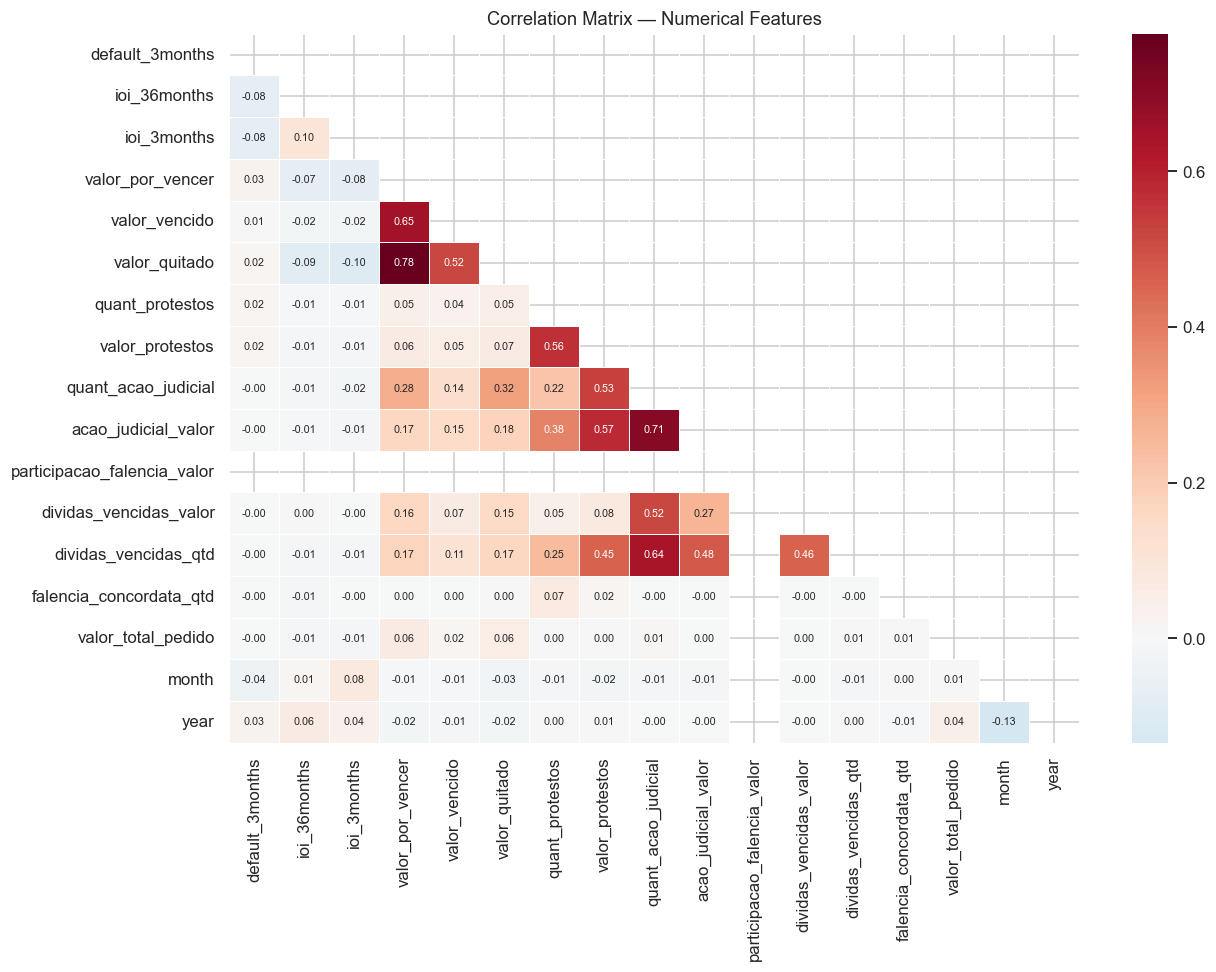

In [30]:
corr_cols = [c for c in NUMERICAL_FEATURES if c in df.columns]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

## 10. Temporal Analysis — Default Rate Over Time

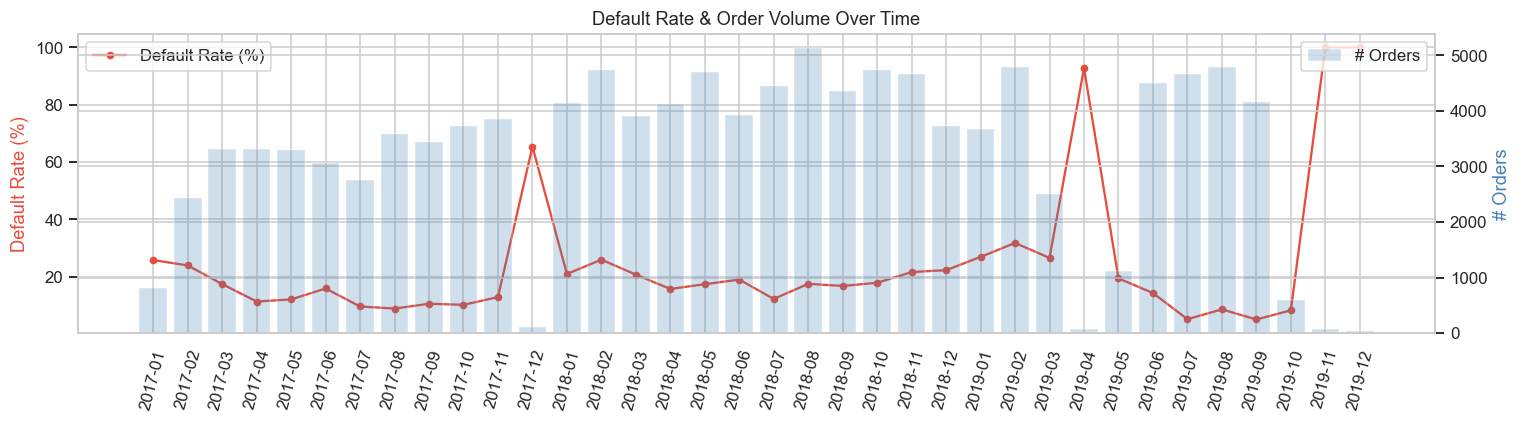

In [31]:
df['period'] = df['year'].astype(str) + '-' + df['month'].astype(int).astype(str).str.zfill(2)
temporal = df.groupby('period')[TARGET].agg(['mean', 'count']).reset_index()
temporal = temporal.sort_values('period')
temporal.columns = ['period', 'default_rate', 'n_orders']

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.plot(temporal['period'], temporal['default_rate'] * 100,
         color='#e74c3c', marker='o', markersize=4, label='Default Rate (%)')
ax2.bar(temporal['period'], temporal['n_orders'],
        alpha=0.25, color='steelblue', label='# Orders')

ax1.set_ylabel('Default Rate (%)', color='#e74c3c')
ax2.set_ylabel('# Orders', color='steelblue')
ax1.set_title('Default Rate & Order Volume Over Time')
ax1.tick_params(axis='x', rotation=75)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 11. Key EDA Insights Summary

| # | Insight | Business Implication |
|---|---------|----------------------|
| 1 | **Class imbalance** — default cases are a minority | Standard accuracy is misleading; use ROC-AUC and Recall |
| 2 | **Financial variables are right-skewed** | RobustScaler recommended over StandardScaler |
| 3 | **Categorical features show different default rates** | Encoding must preserve this signal |
| 4 | **Missing values present** in multiple columns | Median imputation for numerics, mode for categoricals |
| 5 | **Temporal trend** | Possible seasonal pattern — `month`/`year` may add predictive power |
| 6 | **Credit bureau features** (protestos, dívidas vencidas, ações judiciais) | Strong signal: clients with Serasa exposure are more likely to default |